# Palmer Penguins Modeling

Import the Palmer Penguins dataset and print out the first few rows.

Suppose we want to predict `bill_depth_mm` using the other variables in the dataset.

Which variables would we need to **dummify**?

In [1]:
! pip install palmerpenguins

In [2]:
import palmerpenguins
import pandas as pd
import numpy as np
from sklearn.linear_model import LinearRegression

In [3]:
penguins_df = palmerpenguins.load_penguins()
penguins_df.head()

,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex,year
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,male,2007
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,female,2007
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,female,2007
3,Adelie,Torgersen,NaN,NaN,NaN,NaN,NaN,2007
4,Adelie,Torgersen,36.7,19.3,193.0,3450.0,female,2007


We would need to dummify species, island, and sex variables.

Let's use `bill_length_mm` to predict `bill_depth_mm`. Prepare your data and fit the following models on the entire dataset:

* Simple linear regression (e.g. straight-line) model
* Quadratic (degree 2 polynomial) model
* Cubic (degree 3 polynomial) model
* Degree 10 polynomial model

Make predictions for each model and plot your fitted models on the scatterplot.

In [4]:
#clean data
penguins_df = penguins_df.dropna(subset=["bill_length_mm", "bill_depth_mm"])
penguins_df

,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex,year
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,male,2007
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,female,2007
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,female,2007
4,Adelie,Torgersen,36.7,19.3,193.0,3450.0,female,2007
5,Adelie,Torgersen,39.3,20.6,190.0,3650.0,male,2007
...,...,...,...,...,...,...,...,...
339,Chinstrap,Dream,55.8,19.8,207.0,4000.0,male,2009
340,Chinstrap,Dream,43.5,18.1,202.0,3400.0,female,2009
341,Chinstrap,Dream,49.6,18.2,193.0,3775.0,male,2009
342,Chinstrap,Dream,50.8,19.0,210.0,4100.0,male,2009


## Linear regression model

In [5]:
#declare the model
linear_model = LinearRegression()

#fit the model to the data
linear_model.fit(
    X=penguins_df[["bill_length_mm"]],
    y=penguins_df["bill_depth_mm"]
)

LinearRegression()

In [6]:
penguins_df["bill_length_mm"].min()

32.1

In [7]:
penguins_df["bill_length_mm"].max()

59.6

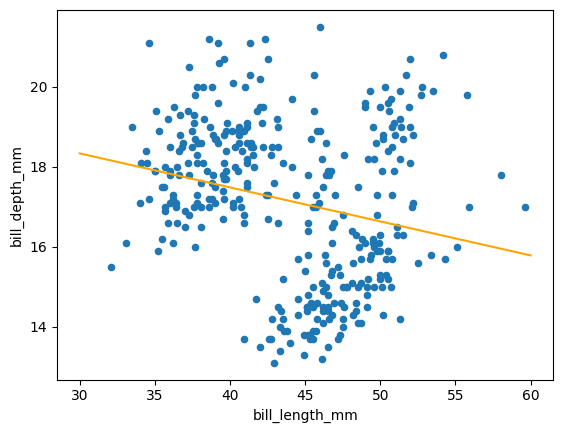

In [8]:
#plot linear regression model
X_new = pd.DataFrame()
X_new["bill_length_mm"] = np.linspace(30, 60, num=1000) #plug in a bunch of values of x into model to predict y
y_new_ = pd.Series(
    linear_model.predict(X_new),
    index=X_new["bill_length_mm"]
)

penguins_df.plot.scatter(x="bill_length_mm", y="bill_depth_mm")
y_new_.plot.line(c = "orange");

In [9]:
#predict values of bill depth from model
penguins_df["bill_depth_predict_linear"] = linear_model.predict(penguins_df[["bill_length_mm"]])
penguins_df

,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex,year,bill_depth_predict_linear
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,male,2007,17.561136
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,female,2007,17.527128
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,female,2007,17.459111
4,Adelie,Torgersen,36.7,19.3,193.0,3450.0,female,2007,17.765187
5,Adelie,Torgersen,39.3,20.6,190.0,3650.0,male,2007,17.544132
...,...,...,...,...,...,...,...,...,...
339,Chinstrap,Dream,55.8,19.8,207.0,4000.0,male,2009,16.141281
340,Chinstrap,Dream,43.5,18.1,202.0,3400.0,female,2009,17.187043
341,Chinstrap,Dream,49.6,18.2,193.0,3775.0,male,2009,16.668413
342,Chinstrap,Dream,50.8,19.0,210.0,4100.0,male,2009,16.566387


## Quadratic (degree 2 polynomial) model

In [10]:
penguins_df["bill_length_square"] = penguins_df["bill_length_mm"]**2
penguins_df

,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex,year,bill_depth_predict_linear,bill_length_square
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,male,2007,17.561136,1528.81
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,female,2007,17.527128,1560.25
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,female,2007,17.459111,1624.09
4,Adelie,Torgersen,36.7,19.3,193.0,3450.0,female,2007,17.765187,1346.89
5,Adelie,Torgersen,39.3,20.6,190.0,3650.0,male,2007,17.544132,1544.49
...,...,...,...,...,...,...,...,...,...,...
339,Chinstrap,Dream,55.8,19.8,207.0,4000.0,male,2009,16.141281,3113.64
340,Chinstrap,Dream,43.5,18.1,202.0,3400.0,female,2009,17.187043,1892.25
341,Chinstrap,Dream,49.6,18.2,193.0,3775.0,male,2009,16.668413,2460.16
342,Chinstrap,Dream,50.8,19.0,210.0,4100.0,male,2009,16.566387,2580.64


In [11]:
#fit quadratic model
square_model = LinearRegression()
square_model.fit(
    X=penguins_df[["bill_length_mm", "bill_length_square"]],
    y=penguins_df["bill_depth_mm"]
)

LinearRegression()

<Axes: xlabel='bill_length_mm', ylabel='bill_depth_mm'>

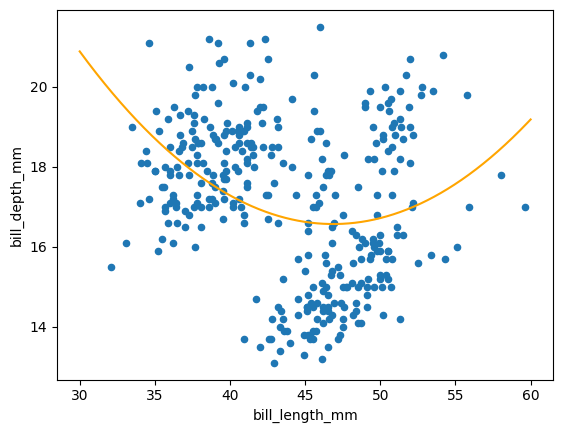

In [12]:
#creating line of best fit and scatter plot
X_new = pd.DataFrame()
X_new["bill_length_mm"] = np.linspace(30, 60, num=1000)
X_new["bill_length_square"] = X_new["bill_length_mm"] ** 2
y_new_ = pd.Series(
    square_model.predict(X_new),
    index=X_new["bill_length_mm"]
)

#scatter plot
penguins_df.plot.scatter(x="bill_length_mm", y="bill_depth_mm")

#line of best fit
y_new_.plot.line(c = "orange")

In [13]:
#predict values of bill depth from model
penguins_df["bill_depth_predict_quad"] = square_model.predict(penguins_df[["bill_length_mm", "bill_length_square"]])
penguins_df

,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex,year,bill_depth_predict_linear,bill_length_square,bill_depth_predict_quad
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,male,2007,17.561136,1528.81,17.484121
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,female,2007,17.527128,1560.25,17.392292
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,female,2007,17.459111,1624.09,17.223194
4,Adelie,Torgersen,36.7,19.3,193.0,3450.0,female,2007,17.765187,1346.89,18.136996
5,Adelie,Torgersen,39.3,20.6,190.0,3650.0,male,2007,17.544132,1544.49,17.437600
...,...,...,...,...,...,...,...,...,...,...,...
339,Chinstrap,Dream,55.8,19.8,207.0,4000.0,male,2009,16.141281,3113.64,17.778189
340,Chinstrap,Dream,43.5,18.1,202.0,3400.0,female,2009,17.187043,1892.25,16.740902
341,Chinstrap,Dream,49.6,18.2,193.0,3775.0,male,2009,16.668413,2460.16,16.681811
342,Chinstrap,Dream,50.8,19.0,210.0,4100.0,male,2009,16.566387,2580.64,16.803027


## Cubic (degree 3 polynomial) model

In [14]:
penguins_df["bill_length_cubed"] = penguins_df["bill_length_mm"]**3
penguins_df

,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex,year,bill_depth_predict_linear,bill_length_square,bill_depth_predict_quad,bill_length_cubed
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,male,2007,17.561136,1528.81,17.484121,59776.471
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,female,2007,17.527128,1560.25,17.392292,61629.875
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,female,2007,17.459111,1624.09,17.223194,65450.827
4,Adelie,Torgersen,36.7,19.3,193.0,3450.0,female,2007,17.765187,1346.89,18.136996,49430.863
5,Adelie,Torgersen,39.3,20.6,190.0,3650.0,male,2007,17.544132,1544.49,17.437600,60698.457
...,...,...,...,...,...,...,...,...,...,...,...,...
339,Chinstrap,Dream,55.8,19.8,207.0,4000.0,male,2009,16.141281,3113.64,17.778189,173741.112
340,Chinstrap,Dream,43.5,18.1,202.0,3400.0,female,2009,17.187043,1892.25,16.740902,82312.875
341,Chinstrap,Dream,49.6,18.2,193.0,3775.0,male,2009,16.668413,2460.16,16.681811,122023.936
342,Chinstrap,Dream,50.8,19.0,210.0,4100.0,male,2009,16.566387,2580.64,16.803027,131096.512


In [15]:
#fit cubic model
cubic_model = LinearRegression()
cubic_model.fit(
    X=penguins_df[["bill_length_mm", "bill_length_square", "bill_length_cubed"]],
    y=penguins_df["bill_depth_mm"]
)

LinearRegression()

<Axes: xlabel='bill_length_mm', ylabel='bill_depth_mm'>

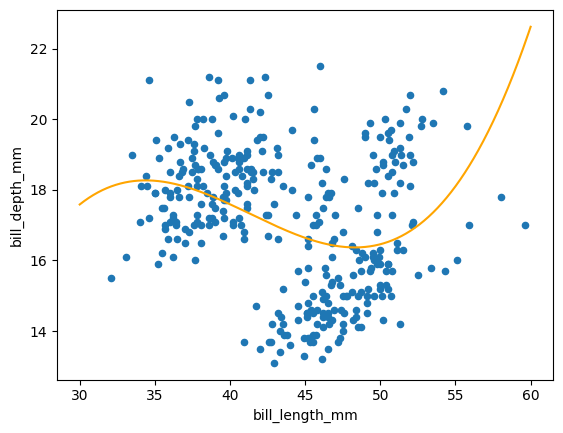

In [16]:
#creating line of best fit and scatter plot
X_new = pd.DataFrame()
X_new["bill_length_mm"] = np.linspace(30, 60, num=1000)
X_new["bill_length_square"] = X_new["bill_length_mm"] ** 2
X_new["bill_length_cubed"] = X_new["bill_length_mm"] ** 3
y_new_ = pd.Series(
    cubic_model.predict(X_new),
    index=X_new["bill_length_mm"]
)

#scatter plot
penguins_df.plot.scatter(x="bill_length_mm", y="bill_depth_mm")

#line of best fit
y_new_.plot.line(c = "orange")

In [17]:
#predict values of bill depth from model
penguins_df["bill_depth_predict_cubic"] = cubic_model.predict(penguins_df[["bill_length_mm", "bill_length_square", "bill_length_cubed"]])
penguins_df

,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex,year,bill_depth_predict_linear,bill_length_square,bill_depth_predict_quad,bill_length_cubed,bill_depth_predict_cubic
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,male,2007,17.561136,1528.81,17.484121,59776.471,17.763289
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,female,2007,17.527128,1560.25,17.392292,61629.875,17.688565
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,female,2007,17.459111,1624.09,17.223194,65450.827,17.532171
4,Adelie,Torgersen,36.7,19.3,193.0,3450.0,female,2007,17.765187,1346.89,18.136996,49430.863,18.128998
5,Adelie,Torgersen,39.3,20.6,190.0,3650.0,male,2007,17.544132,1544.49,17.437600,60698.457,17.726273
...,...,...,...,...,...,...,...,...,...,...,...,...,...
339,Chinstrap,Dream,55.8,19.8,207.0,4000.0,male,2009,16.141281,3113.64,17.778189,173741.112,18.604071
340,Chinstrap,Dream,43.5,18.1,202.0,3400.0,female,2009,17.187043,1892.25,16.740902,82312.875,16.893127
341,Chinstrap,Dream,49.6,18.2,193.0,3775.0,male,2009,16.668413,2460.16,16.681811,122023.936,16.420601
342,Chinstrap,Dream,50.8,19.0,210.0,4100.0,male,2009,16.566387,2580.64,16.803027,131096.512,16.572067


## Degree 10 polynomial model

In [18]:
penguins_df["bill_length_fourth"] = penguins_df["bill_length_mm"]**4
penguins_df["bill_length_fifth"] = penguins_df["bill_length_mm"]**5
penguins_df["bill_length_sixth"] = penguins_df["bill_length_mm"]**6
penguins_df["bill_length_seventh"] = penguins_df["bill_length_mm"]**7
penguins_df["bill_length_eighth"] = penguins_df["bill_length_mm"]**8
penguins_df["bill_length_ninth"] = penguins_df["bill_length_mm"]**9
penguins_df["bill_length_tenth"] = penguins_df["bill_length_mm"]**10
penguins_df

,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex,year,bill_depth_predict_linear,bill_length_square,bill_depth_predict_quad,bill_length_cubed,bill_depth_predict_cubic,bill_length_fourth,bill_length_fifth,bill_length_sixth,bill_length_seventh,bill_length_eighth,bill_length_ninth,bill_length_tenth
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,male,2007,17.561136,1528.81,17.484121,59776.471,17.763289,2.337260e+06,9.138687e+07,3.573226e+09,1.397132e+11,5.462784e+12,2.135949e+14,8.351559e+15
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,female,2007,17.527128,1560.25,17.392292,61629.875,17.688565,2.434380e+06,9.615801e+07,3.798241e+09,1.500305e+11,5.926206e+12,2.340851e+14,9.246363e+15
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,female,2007,17.459111,1624.09,17.223194,65450.827,17.532171,2.637668e+06,1.062980e+08,4.283811e+09,1.726376e+11,6.957294e+12,2.803790e+14,1.129927e+16
4,Adelie,Torgersen,36.7,19.3,193.0,3450.0,female,2007,17.765187,1346.89,18.136996,49430.863,18.128998,1.814113e+06,6.657794e+07,2.443410e+09,8.967315e+10,3.291005e+12,1.207799e+14,4.432621e+15
5,Adelie,Torgersen,39.3,20.6,190.0,3650.0,male,2007,17.544132,1544.49,17.437600,60698.457,17.726273,2.385449e+06,9.374816e+07,3.684303e+09,1.447931e+11,5.690369e+12,2.236315e+14,8.788717e+15
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
339,Chinstrap,Dream,55.8,19.8,207.0,4000.0,male,2009,16.141281,3113.64,17.778189,173741.112,18.604071,9.694754e+06,5.409673e+08,3.018597e+10,1.684377e+12,9.398826e+13,5.244545e+15,2.926456e+17
340,Chinstrap,Dream,43.5,18.1,202.0,3400.0,female,2009,17.187043,1892.25,16.740902,82312.875,16.893127,3.580610e+06,1.557565e+08,6.775409e+09,2.947303e+11,1.282077e+13,5.577034e+14,2.426010e+16
341,Chinstrap,Dream,49.6,18.2,193.0,3775.0,male,2009,16.668413,2460.16,16.681811,122023.936,16.420601,6.052387e+06,3.001984e+08,1.488984e+10,7.385361e+11,3.663139e+13,1.816917e+15,9.011908e+16
342,Chinstrap,Dream,50.8,19.0,210.0,4100.0,male,2009,16.566387,2580.64,16.803027,131096.512,16.572067,6.659703e+06,3.383129e+08,1.718630e+10,8.730638e+11,4.435164e+13,2.253063e+15,1.144556e+17


In [19]:
degree_ten_model = LinearRegression()
degree_ten_model.fit(
    X=penguins_df[["bill_length_mm", "bill_length_square", "bill_length_cubed", "bill_length_fourth", "bill_length_fifth", "bill_length_sixth", "bill_length_seventh", "bill_length_eighth", "bill_length_ninth", "bill_length_tenth"]],
    y=penguins_df["bill_depth_mm"]
)

LinearRegression()

<Axes: xlabel='bill_length_mm', ylabel='bill_depth_mm'>

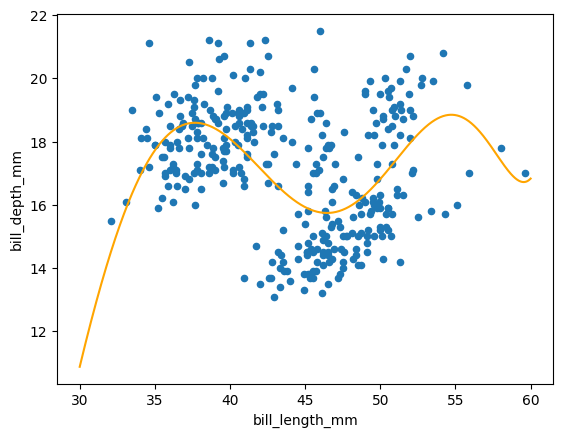

In [20]:
#creating line of best fit and scatter plot
X_new = pd.DataFrame()
X_new["bill_length_mm"] = np.linspace(30, 60, num=1000)
X_new["bill_length_square"] = X_new["bill_length_mm"] ** 2
X_new["bill_length_cubed"] = X_new["bill_length_mm"] ** 3
X_new["bill_length_fourth"] = X_new["bill_length_mm"] ** 4
X_new["bill_length_fifth"] = X_new["bill_length_mm"] ** 5
X_new["bill_length_sixth"] = X_new["bill_length_mm"] ** 6
X_new["bill_length_seventh"] = X_new["bill_length_mm"] ** 7
X_new["bill_length_eighth"] = X_new["bill_length_mm"] ** 8
X_new["bill_length_ninth"] = X_new["bill_length_mm"] ** 9
X_new["bill_length_tenth"] = X_new["bill_length_mm"] ** 10
y_new_ = pd.Series(
    degree_ten_model.predict(X_new),
    index=X_new["bill_length_mm"]
)

#scatter plot
penguins_df.plot.scatter(x="bill_length_mm", y="bill_depth_mm")

#line of best fit
y_new_.plot.line(c = "orange")

* Are any of the models above underfitting the data? If so, which ones and how can you tell?

It appears that the quadratic model underfits the data. It doesn't seem to capture enough of the the relationship between bill length and bill depth.

* Are any of the models above overfitting the data? If so, which ones and how can you tell?

Yes, it appears that the cubic and degree ten polynomial models are overfitting the data since they are fitting the nuances (curves/noise) of the points in this specific data set.

* Which of the above models do you think fits the data best and why?

I would say that the linear model fits the data the best. It captures the decreasing relationship between bill length and bill depth while not capturing the nuances of this specific data set.